   # 05 — Functional Model Interpretability Notebook







   This notebook visualises and interprets the final functional classification results



   without retraining the heavy models from notebook 04.







   It does five things:







   1. Loads saved outputs from notebook 04.



   2. Recreates final comparison plots from saved summary tables.



   3. Visualises class-level spectral structure.



   4. Visualises FPCA / FPLS score-space separation.



   5. Visualises model-based and distance-based interpretability:



      - nearest-neighbour example



      - distance contribution over wavelength



      - logistic regression coefficient function



      - linear SVM weight function



      - comparison of linear-model discrimination curves







   Required inputs:



   - final_functional_final_df.csv



   - final_functional_pretty_table.csv



   - final_functional_linear_summary.csv



   - final_functional_interpretability_payload.npz



   - final_functional_nearest_neighbour_table.csv







   Note:



   Since the report is written in Lithuanian, the final interpretability figures are also presented in Lithuanian in order to keep the terminology, captions, and discussion visually consistent throughout the report.

In [24]:
from __future__ import annotations

import warnings
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)




   ## 1. Configuration

In [ ]:
BASE_DIR = Path.cwd()/ "og_data"
RESULTS_DIR = Path.cwd() / "results" / "final_functional"
OUT_DIR = Path.cwd() / "results" / "functional_interpretability"
OUT_DIR.mkdir(parents=True, exist_ok=True)

NOTEBOOK_NAME = "05_functional_interpretability"
TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M")

   ## 2. File helpers

In [4]:
def find_latest(pattern: str, folder: Path) -> Path | None:
    matches = sorted(folder.glob(pattern))
    return matches[-1] if matches else None




   ## 3. Locate notebook 04 outputs

In [5]:
FINAL_DF_FILE = find_latest("04_final_functional_final_df_*.csv", RESULTS_DIR)
PRETTY_TABLE_FILE = find_latest("04_final_functional_pretty_table_*.csv", RESULTS_DIR)
LINEAR_SUMMARY_FILE = find_latest("04_final_functional_linear_summary_*.csv", RESULTS_DIR)
INTERP_PAYLOAD_FILE = find_latest("04_final_functional_interpretability_payload_*.npz", RESULTS_DIR)
NN_TABLE_FILE = find_latest("04_final_functional_nearest_neighbour_table_*.csv", RESULTS_DIR)

required = {
    "FINAL_DF_FILE": FINAL_DF_FILE,
    "PRETTY_TABLE_FILE": PRETTY_TABLE_FILE,
    "LINEAR_SUMMARY_FILE": LINEAR_SUMMARY_FILE,
    "INTERP_PAYLOAD_FILE": INTERP_PAYLOAD_FILE,
    "NN_TABLE_FILE": NN_TABLE_FILE,
}

missing = [k for k, v in required.items() if v is None]
if missing:
    raise FileNotFoundError(
        "Missing required 04 outputs: " + ", ".join(missing)
    )

print("Loaded files:")
for k, v in required.items():
    print(f"- {k}: {v}")




Loaded files:
- FINAL_DF_FILE: c:\Users\Lenovo\Documents\VDA\Bakalauras\astroflow_project\results\final_functional\04_final_functional_final_df_20260410_1655.csv
- PRETTY_TABLE_FILE: c:\Users\Lenovo\Documents\VDA\Bakalauras\astroflow_project\results\final_functional\04_final_functional_pretty_table_20260410_1655.csv
- LINEAR_SUMMARY_FILE: c:\Users\Lenovo\Documents\VDA\Bakalauras\astroflow_project\results\final_functional\04_final_functional_linear_summary_20260410_1655.csv
- INTERP_PAYLOAD_FILE: c:\Users\Lenovo\Documents\VDA\Bakalauras\astroflow_project\results\final_functional\04_final_functional_interpretability_payload_20260410_1655.npz
- NN_TABLE_FILE: c:\Users\Lenovo\Documents\VDA\Bakalauras\astroflow_project\results\final_functional\04_final_functional_nearest_neighbour_table_20260410_1655.csv


   ## 4. Load saved tables and interpretability arrays

In [6]:
final_df = pd.read_csv(FINAL_DF_FILE)
pretty_table = pd.read_csv(PRETTY_TABLE_FILE)
df_linear_summary = pd.read_csv(LINEAR_SUMMARY_FILE)
nn_table = pd.read_csv(NN_TABLE_FILE)

payload = np.load(INTERP_PAYLOAD_FILE)

wavelengths = payload["wavelengths"]
y = payload["y"]

mean_0 = payload["mean_0"]
mean_1 = payload["mean_1"]
diff_10 = payload["diff_10"]

scores_fpca = payload["scores_fpca"]
scores_fpls = payload["scores_fpls"]

x_query = payload["x_query"]
closest_curve = payload["closest_curve"]
abs_diff = payload["abs_diff"]

beta_logreg = payload["beta_logreg"]
beta_svm = payload["beta_svm"]

print("Final DF shape:", final_df.shape)
print("Pretty table shape:", pretty_table.shape)
print("Linear summary shape:", df_linear_summary.shape)
print("NN table shape:", nn_table.shape)
print("Payload arrays loaded successfully.")




Final DF shape: (11, 21)
Pretty table shape: (11, 13)
Linear summary shape: (3, 20)
NN table shape: (5, 3)
Payload arrays loaded successfully.


   ## 5. Quick final view

In [7]:
rank_by_f1 = final_df.sort_values(
    ["f1_mean", "pr_auc_mean", "roc_auc_mean"],
    ascending=False,
    na_position="last",
).reset_index(drop=True)

print("\n=== TOP 15 BY F1 ===")
print(
    rank_by_f1[
        ["family", "method", "representation", "tuning", "f1_mean", "pr_auc_mean", "roc_auc_mean"]
    ].head(15).to_string(index=False)
)

print("\n=== PRETTY TABLE HEAD ===")
print(pretty_table.head(15).to_string(index=False))





=== TOP 15 BY F1 ===
                   family                              method                representation                           tuning  f1_mean  pr_auc_mean  roc_auc_mean
        Functional linear               Functional linear SVM L2-normalised sampled spectra   inner-CV C | mean best C=3.394 0.809560     0.864106      0.915193
        Functional linear Functional logistic regression (L2) L2-normalised sampled spectra inner-CV C | mean best C=0.01812 0.805820     0.861977      0.914110
        Functional linear Functional logistic regression (L1) L2-normalised sampled spectra   inner-CV C | mean best C=200.3 0.793361     0.853528      0.911170
Distance-based functional           weighted kNN + seuclidean L2-normalised sampled spectra                              k=5 0.773768     0.808304      0.891048
Distance-based functional            weighted kNN + euclidean L2-normalised sampled spectra                              k=5 0.698724     0.736810      0.854622
Distance-bas

   ## 6. Final comparison plots from notebook 04 results

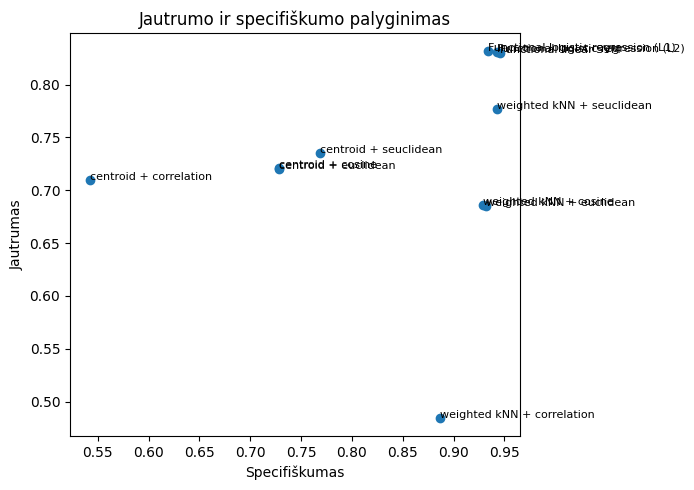

In [8]:
trade_df = rank_by_f1.dropna(subset=["specificity_mean", "sensitivity_mean"]).head(15).copy()

plt.figure(figsize=(7, 5))
plt.scatter(trade_df["specificity_mean"], trade_df["sensitivity_mean"])
for _, r in trade_df.iterrows():
    plt.annotate(r["method"], (r["specificity_mean"], r["sensitivity_mean"]), fontsize=8)
plt.xlabel("Specifiškumas")
plt.ylabel("Jautrumas")
plt.title("Jautrumo ir specifiškumo palyginimas")
plt.tight_layout()
plt.savefig(OUT_DIR / f"{NOTEBOOK_NAME}_sens_vs_spec_{TIMESTAMP}.png", dpi=200)
plt.show()
plt.close()




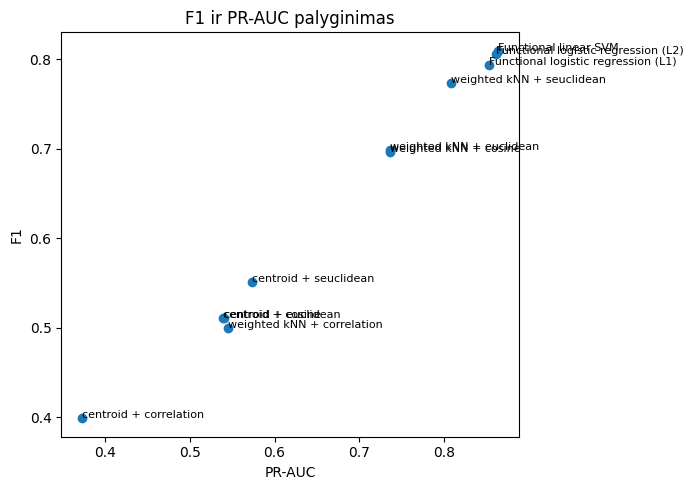

In [9]:
scatter_df = rank_by_f1.dropna(subset=["pr_auc_mean", "f1_mean"]).head(20).copy()

plt.figure(figsize=(7, 5))
plt.scatter(scatter_df["pr_auc_mean"], scatter_df["f1_mean"])
for _, r in scatter_df.iterrows():
    plt.annotate(r["method"], (r["pr_auc_mean"], r["f1_mean"]), fontsize=8)
plt.xlabel("PR-AUC")
plt.ylabel("F1")
plt.title("F1 ir PR-AUC palyginimas")
plt.tight_layout()
plt.savefig(OUT_DIR / f"{NOTEBOOK_NAME}_f1_vs_pr_auc_{TIMESTAMP}.png", dpi=200)
plt.show()
plt.close()




   ## 7. Class mean spectra

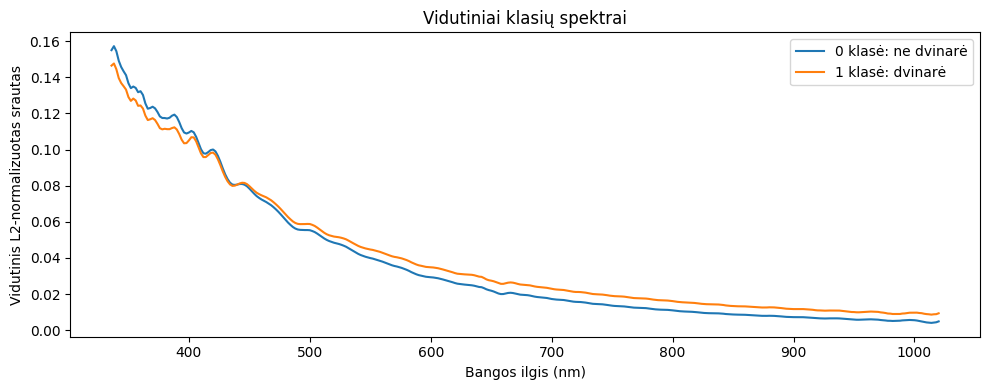

In [10]:
plt.figure(figsize=(10, 4))
plt.plot(wavelengths, mean_0, label="0 klasė: ne dvinarė")
plt.plot(wavelengths, mean_1, label="1 klasė: dvinarė")
plt.xlabel("Bangos ilgis (nm)")
plt.ylabel("Vidutinis L2-normalizuotas srautas")
plt.title("Vidutiniai klasių spektrai")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / f"{NOTEBOOK_NAME}_class_mean_spectra_{TIMESTAMP}.png", dpi=200)
plt.show()
plt.close()




   ## 8. Mean spectral difference

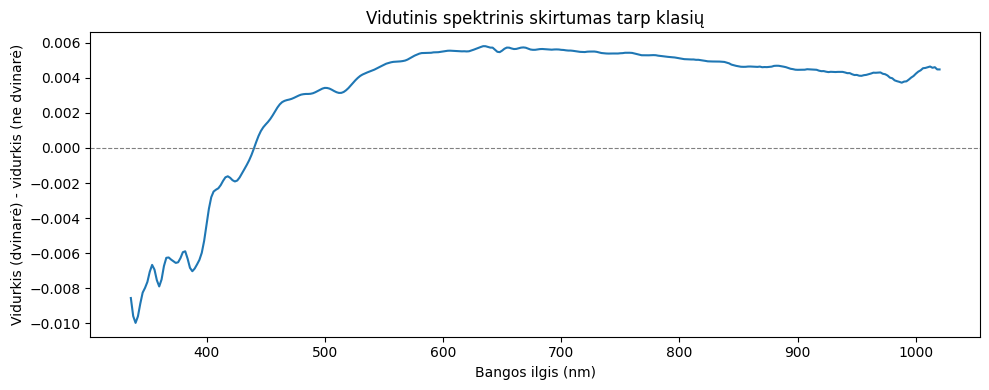

In [11]:
plt.figure(figsize=(10, 4))
plt.plot(wavelengths, diff_10)
plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)
plt.xlabel("Bangos ilgis (nm)")
plt.ylabel("Vidurkis (dvinarė) - vidurkis (ne dvinarė)")
plt.title("Vidutinis spektrinis skirtumas tarp klasių")
plt.tight_layout()
plt.savefig(OUT_DIR / f"{NOTEBOOK_NAME}_mean_difference_{TIMESTAMP}.png", dpi=200)
plt.show()
plt.close()




   ## 9. FPCA class separation

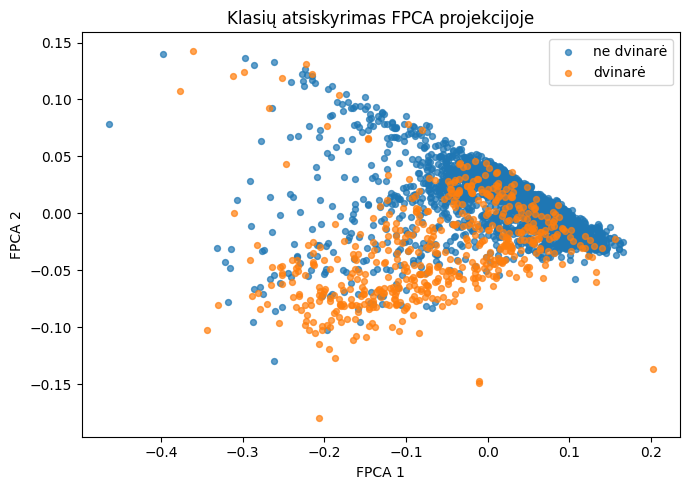

In [12]:
plt.figure(figsize=(7, 5))
plt.scatter(scores_fpca[y == 0, 0], scores_fpca[y == 0, 1], s=18, alpha=0.7, label="ne dvinarė")
plt.scatter(scores_fpca[y == 1, 0], scores_fpca[y == 1, 1], s=18, alpha=0.7, label="dvinarė")
plt.xlabel("FPCA 1")
plt.ylabel("FPCA 2")
plt.title("Klasių atsiskyrimas FPCA projekcijoje")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / f"{NOTEBOOK_NAME}_fpca_scatter_{TIMESTAMP}.png", dpi=200)
plt.show()
plt.close()




   ## 10. FPLS class separation

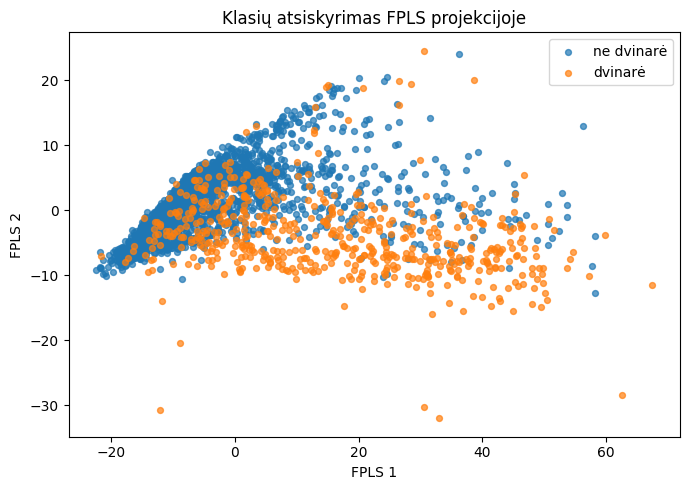

In [13]:
plt.figure(figsize=(7, 5))
plt.scatter(scores_fpls[y == 0, 0], scores_fpls[y == 0, 1], s=18, alpha=0.7, label="ne dvinarė")
plt.scatter(scores_fpls[y == 1, 0], scores_fpls[y == 1, 1], s=18, alpha=0.7, label="dvinarė")
plt.xlabel("FPLS 1")
plt.ylabel("FPLS 2")
plt.title("Klasių atsiskyrimas FPLS projekcijoje")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / f"{NOTEBOOK_NAME}_fpls_scatter_{TIMESTAMP}.png", dpi=200)
plt.show()
plt.close()




   ## 11. Nearest-neighbour example

Nearest-neighbour table:
 train_index_local  distance  label
              1897  0.047313      1
               378  0.047321      1
              1120  0.049061      1
              1714  0.049792      1
               595  0.049818      1


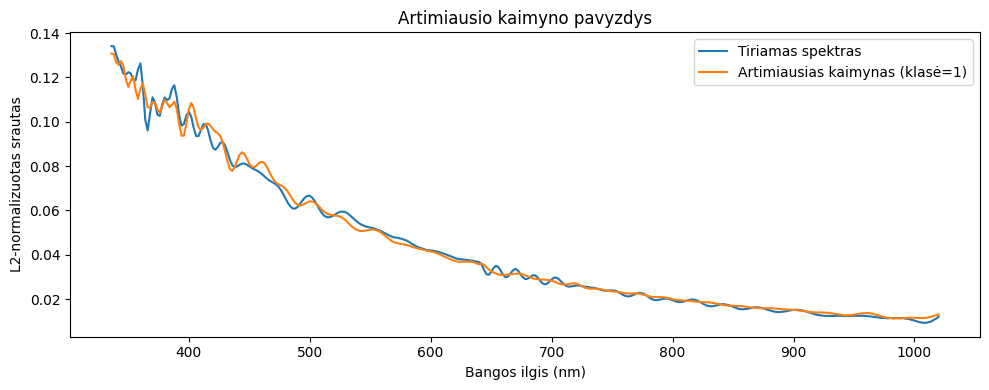

In [14]:
print("Nearest-neighbour table:")
print(nn_table.to_string(index=False))

plt.figure(figsize=(10, 4))
plt.plot(wavelengths, x_query, label="Tiriamas spektras")
plt.plot(wavelengths, closest_curve, label=f"Artimiausias kaimynas (klasė={int(nn_table.iloc[0]['label'])})")
plt.xlabel("Bangos ilgis (nm)")
plt.ylabel("L2-normalizuotas srautas")
plt.title("Artimiausio kaimyno pavyzdys")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / f"{NOTEBOOK_NAME}_nearest_neighbour_example_{TIMESTAMP}.png", dpi=200)
plt.show()
plt.close()




   ## 12. Distance contribution over wavelength

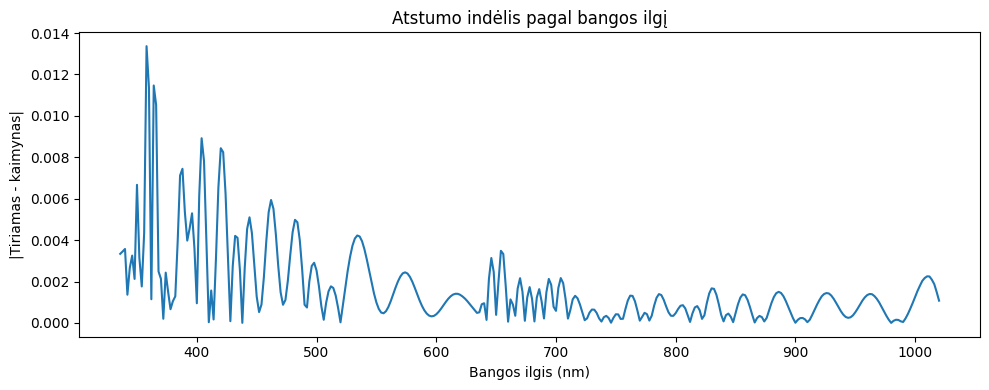

In [15]:
plt.figure(figsize=(10, 4))
plt.plot(wavelengths, abs_diff)
plt.xlabel("Bangos ilgis (nm)")
plt.ylabel("|Tiriamas - kaimynas|")
plt.title("Atstumo indėlis pagal bangos ilgį")
plt.tight_layout()
plt.savefig(OUT_DIR / f"{NOTEBOOK_NAME}_distance_contribution_{TIMESTAMP}.png", dpi=200)
plt.show()
plt.close()




   ## 13. Functional logistic regression coefficient function

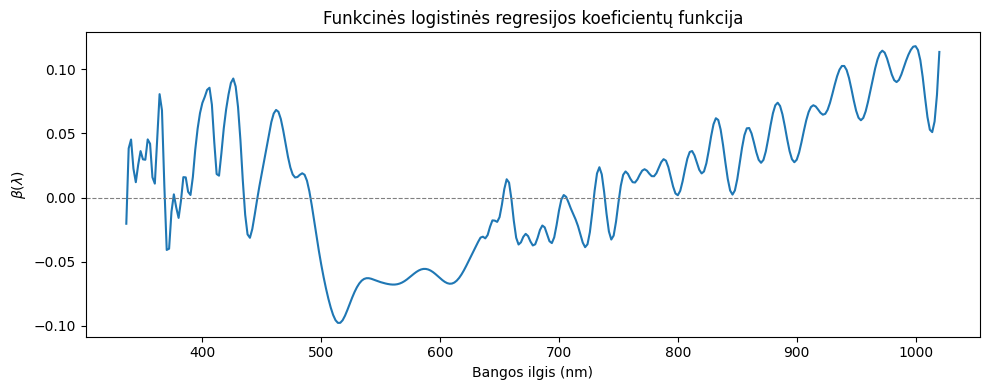

In [16]:
plt.figure(figsize=(10, 4))
plt.plot(wavelengths, beta_logreg)
plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)
plt.xlabel("Bangos ilgis (nm)")
plt.ylabel(r"$\beta(\lambda)$")
plt.title("Funkcinės logistinės regresijos koeficientų funkcija")
plt.tight_layout()
plt.savefig(OUT_DIR / f"{NOTEBOOK_NAME}_beta_logreg_{TIMESTAMP}.png", dpi=200)
plt.show()
plt.close()




   ## 14. Functional linear SVM weight function

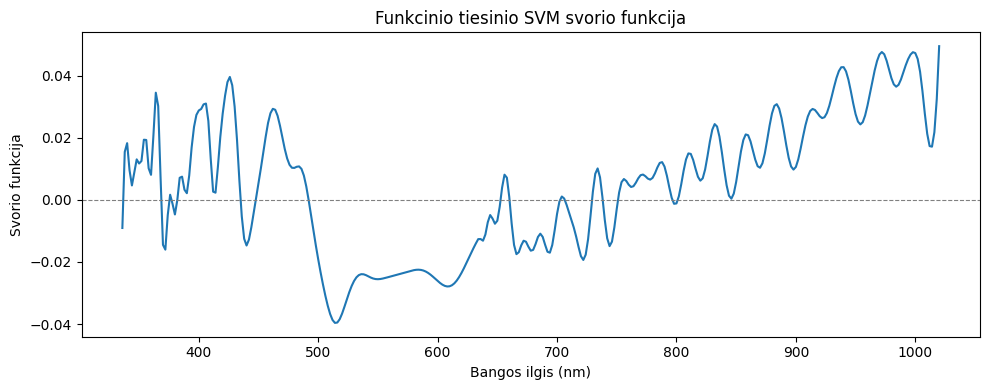

In [17]:
plt.figure(figsize=(10, 4))
plt.plot(wavelengths, beta_svm)
plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)
plt.xlabel("Bangos ilgis (nm)")
plt.ylabel("Svorio funkcija")
plt.title("Funkcinio tiesinio SVM svorio funkcija")
plt.tight_layout()
plt.savefig(OUT_DIR / f"{NOTEBOOK_NAME}_beta_svm_{TIMESTAMP}.png", dpi=200)
plt.show()
plt.close()




   ## 15. Comparison of linear-model discrimination curves

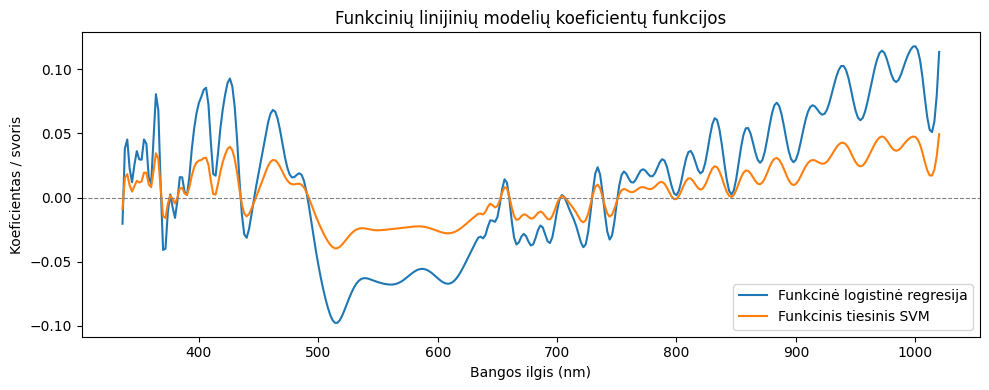

In [18]:
plt.figure(figsize=(10, 4))
plt.plot(wavelengths, beta_logreg, label="Funkcinė logistinė regresija")
plt.plot(wavelengths, beta_svm, label="Funkcinis tiesinis SVM")
plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)
plt.xlabel("Bangos ilgis (nm)")
plt.ylabel("Koeficientas / svoris")
plt.title("Funkcinių linijinių modelių koeficientų funkcijos")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / f"{NOTEBOOK_NAME}_beta_compare_{TIMESTAMP}.png", dpi=200)
plt.show()
plt.close()




   ## 16. Short numerical diagnostics for the coefficient curves

In [19]:
coef_df = pd.DataFrame({
    "wavelength": wavelengths,
    "beta_logreg": beta_logreg,
    "beta_svm": beta_svm,
    "abs_beta_logreg": np.abs(beta_logreg),
    "abs_beta_svm": np.abs(beta_svm),
})

top_logreg = coef_df.nlargest(15, "abs_beta_logreg")[["wavelength", "beta_logreg", "abs_beta_logreg"]]
top_svm = coef_df.nlargest(15, "abs_beta_svm")[["wavelength", "beta_svm", "abs_beta_svm"]]

print("\n=== TOP 15 |beta| REGIONS: FUNCTIONAL LOGISTIC REGRESSION ===")
print(top_logreg.to_string(index=False))

print("\n=== TOP 15 |weight| REGIONS: FUNCTIONAL LINEAR SVM ===")
print(top_svm.to_string(index=False))





=== TOP 15 |beta| REGIONS: FUNCTIONAL LOGISTIC REGRESSION ===
 wavelength  beta_logreg  abs_beta_logreg
     1000.0     0.118010         0.118010
      998.0     0.117601         0.117601
      996.0     0.115144         0.115144
     1002.0     0.115019         0.115019
      972.0     0.114491         0.114491
     1020.0     0.113504         0.113504
      974.0     0.112980         0.112980
      970.0     0.112563         0.112563
      994.0     0.111392         0.111392
      976.0     0.108387         0.108387
      968.0     0.107679         0.107679
     1004.0     0.107094         0.107094
      992.0     0.106659         0.106659
      940.0     0.102570         0.102570
      938.0     0.102553         0.102553

=== TOP 15 |weight| REGIONS: FUNCTIONAL LINEAR SVM ===
 wavelength  beta_svm  abs_beta_svm
     1020.0  0.049465      0.049465
      972.0  0.047579      0.047579
      998.0  0.047524      0.047524
     1000.0  0.047249      0.047249
      974.0  0.046862      0.

   ## 17. Save compact interpretability tables

In [20]:
coef_table_path = OUT_DIR / f"{NOTEBOOK_NAME}_coefficient_table_{TIMESTAMP}.csv"
top_logreg_path = OUT_DIR / f"{NOTEBOOK_NAME}_top_beta_logreg_{TIMESTAMP}.csv"
top_svm_path = OUT_DIR / f"{NOTEBOOK_NAME}_top_beta_svm_{TIMESTAMP}.csv"

coef_df.to_csv(coef_table_path, index=False)
top_logreg.to_csv(top_logreg_path, index=False)
top_svm.to_csv(top_svm_path, index=False)

print("Saved:")
print("-", coef_table_path)
print("-", top_logreg_path)
print("-", top_svm_path)

Saved:
- c:\Users\Lenovo\Documents\VDA\Bakalauras\astroflow_project\results\functional_interpretability\05_functional_interpretability_coefficient_table_20260411_1548.csv
- c:\Users\Lenovo\Documents\VDA\Bakalauras\astroflow_project\results\functional_interpretability\05_functional_interpretability_top_beta_logreg_20260411_1548.csv
- c:\Users\Lenovo\Documents\VDA\Bakalauras\astroflow_project\results\functional_interpretability\05_functional_interpretability_top_beta_svm_20260411_1548.csv
